# EDS 232 Kaggle Competition (2026)
Authors: Melannie Moreno Rolon, Ixel Medrano, Vedika Shirtekar

## Background
This needs a markdown section that explains what the notebook contains and the data being used.

## Setup (5 pts)
load your libraries and read in the data. 

In [44]:
# Import relevant libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score



Luckily, our train and test sets are separated, so we don't have to worry about splitting our data. 

In [21]:
# Import train and test sets
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

In [22]:
# Show the first few rows of the training data
train.head()

,id,CTDTEMP_ITS90,Salinity_PSS78,Depth,TA,DIC
0,0,15.36,33.6095,10.0,2241.0,1989.4
1,1,11.23,33.6095,10.0,2241.0,1989.8
2,2,11.23,33.6095,10.0,2241.0,1989.3
3,3,11.23,33.6095,10.0,2241.0,1988.6
4,4,15.06,33.2820,10.0,2241.0,1991.5


In [24]:
# Store features in an array to extract
features = ["CTDTEMP_ITS90", "TA", "Salinity_PSS78", "Depth"]
features 

# Extract from train and store as X and y
X_train =  train[features]
y_train = train["DIC"]

# Extract from test and store as X_test
X_test = test[features]

## Exploratory Data Analysis (35) pts
explore the features and target: distributions, relationships, and anything that may inform your modeling choices. Include at least one visualization

We will explore properties of the features (`X_train`) and target/outcome (`y_train`).

In [17]:
# What does X_train contain? 
X_train.head() # It is a df with all features except DIC

,CTDTEMP_ITS90,TA,Salinity_PSS78,Depth
0,15.36,2241.0,33.6095,10.0
1,11.23,2241.0,33.6095,10.0
2,11.23,2241.0,33.6095,10.0
3,11.23,2241.0,33.6095,10.0
4,15.06,2241.0,33.2820,10.0


In [ ]:
# Do we need to impute anything? Check for missing values 
features_missing = X_train.isnull().sum()
features_missing

CTDTEMP_ITS90     0
TA                0
Salinity_PSS78    0
Depth             0
dtype: int64

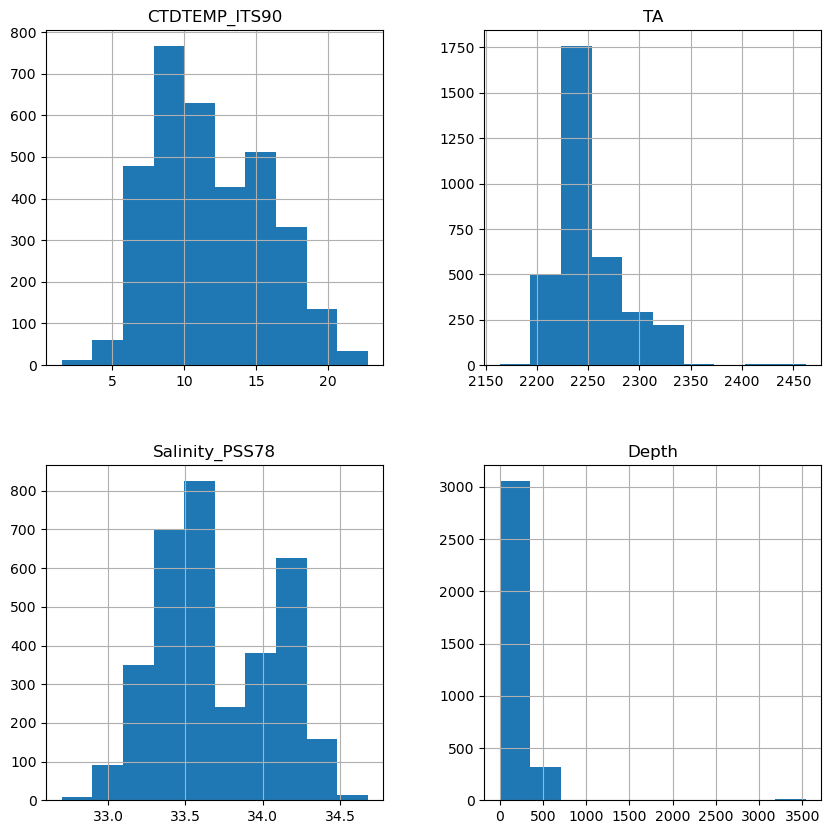

In [26]:
# There do not seem to be any missing values, so let's check the distribution of the features to see if we need to do any transformations.
X_train.hist(figsize=(10,10))
plt.show()

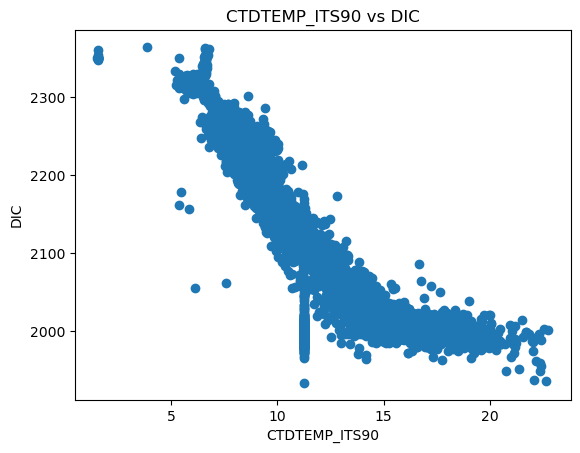

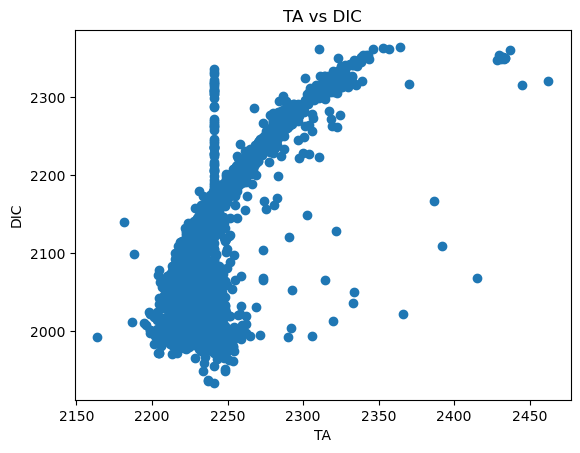

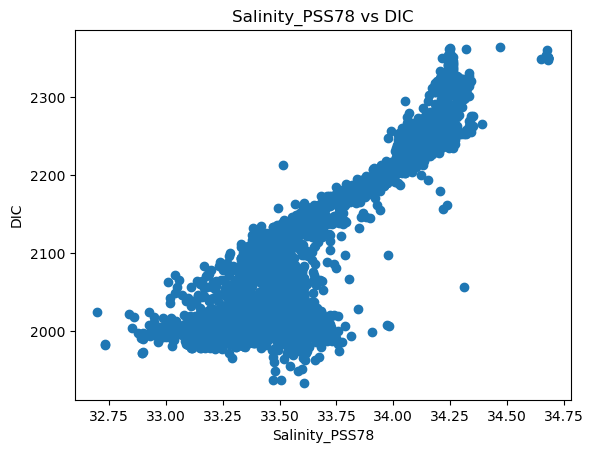

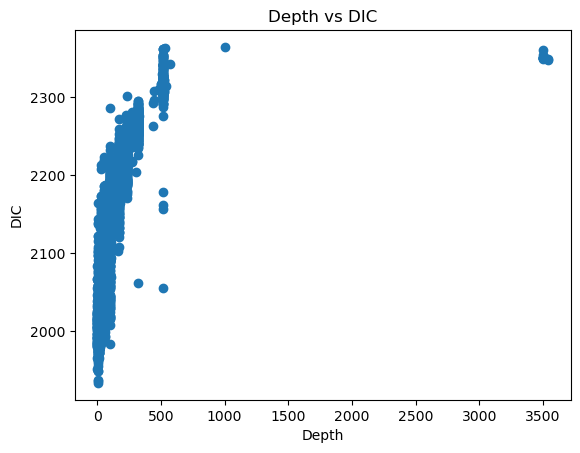

In [ ]:
# Looks good! What if we want to see potential linear relationships between the features and DIC? We can make scatter plots of each feature against DIC.
# Scatterplots are not that easy to create in Python, but we can use a for loop to make one for each feature
for feature in features:
    plt.scatter(X_train[feature], y_train)
    plt.xlabel(feature)
    plt.ylabel("DIC")
    plt.title(f"{feature} vs DIC")
    plt.show()

In [28]:
# There are some outliers... 
train.describe()

,id,CTDTEMP_ITS90,Salinity_PSS78,Depth,TA,DIC
count,3389.000000,3389.000000,3389.000000,3389.000000,3389.000000,3389.000000
mean,2148.460018,11.819258,33.701898,144.232546,2251.047300,2117.764680
std,1220.849812,3.905980,0.375517,262.640488,32.675546,116.876574
min,0.000000,1.520000,32.700000,0.000000,2163.800000,1934.100000
25%,1082.000000,8.749000,33.415000,10.000000,2229.400000,2008.700000
50%,2161.000000,11.230000,33.609500,50.000000,2241.000000,2083.300000
75%,3211.000000,14.916000,34.068000,230.000000,2267.100000,2225.600000
max,4235.000000,22.750000,34.680000,3542.000000,2462.300000,2364.600000


In [29]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3389 entries, 0 to 3388
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              3389 non-null   int64  
 1   CTDTEMP_ITS90   3389 non-null   float64
 2   Salinity_PSS78  3389 non-null   float64
 3   Depth           3389 non-null   float64
 4   TA              3389 non-null   float64
 5   DIC             3389 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 159.0 KB


In [ ]:
# See each feature's correlation with the target
cols = ["CTDTEMP_ITS90", "TA", "Salinity_PSS78", "Depth", "DIC"]
corr = train[cols].corr()
print(corr)

                CTDTEMP_ITS90        TA  Salinity_PSS78     Depth       DIC
CTDTEMP_ITS90        1.000000 -0.673803       -0.778143 -0.606716 -0.880959
TA                  -0.673803  1.000000        0.855702  0.762256  0.803202
Salinity_PSS78      -0.778143  0.855702        1.000000  0.624730  0.898543
Depth               -0.606716  0.762256        0.624730  1.000000  0.643485
DIC                 -0.880959  0.803202        0.898543  0.643485  1.000000


## Models (25 pts) 
fit at least two different models, each with a hyperparameter search grid (if applicable), showing your tuning process and how you select the best configuration. 

### Ridge Regression

In [ ]:
# Load, split, and scale (necessary for ridge regression)
train = pd.read_csv("data/train.csv")
features = ["CTDTEMP_ITS90", "TA", "Salinity_PSS78", "Depth"]
X_train = train[features]
y_train = train["DIC"]
X_test = test[features]

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only
X_test_scaled   = scaler.transform(X_test)  # reuse train stats


In [ ]:
# Now we need to tune alpha with grid search (CV gives comparison MSE)
param_grid = {"alpha": np.logspace(-3, 3, 50)}
ridge_search = GridSearchCV(
    Ridge(), param_grid, scoring="neg_mean_squared_error", cv=5
)
ridge_search.fit(X_train_scaled, y_train)

best_alpha = ridge_search.best_params_["alpha"]
print("Best alpha:", best_alpha)
print("Best CV MSE:", -ridge_search.best_score_)   # Ridge comparison number


Best alpha: 3.5564803062231287
Best CV MSE: 1413.2737290663076


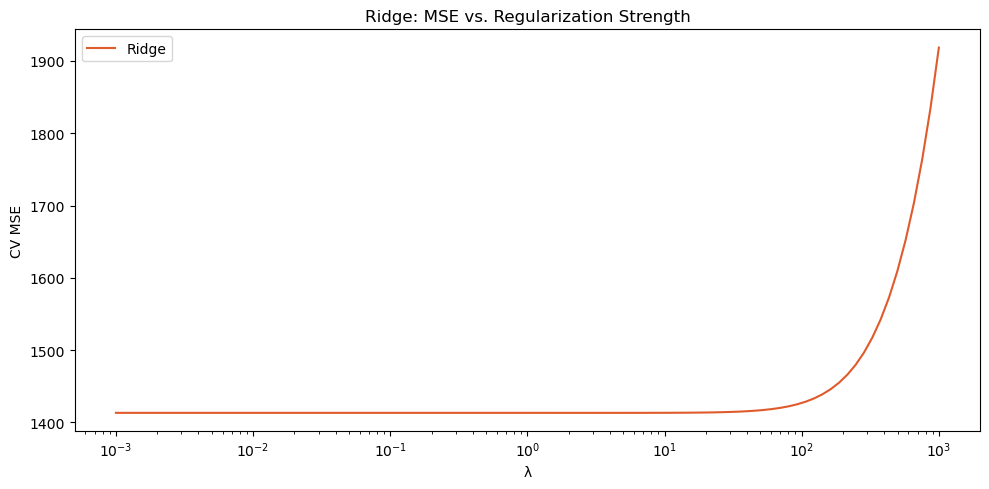

In [ ]:
# Visualize the CV MSE for each alpha (taken from lab)
mse_ridge = []
lambdas = np.logspace(-3, 3, 100)
for lam in lambdas:
    scores = cross_val_score(
        Ridge(alpha=lam), X_train_scaled, y_train,
        scoring="neg_mean_squared_error", cv=5
    )
    mse_ridge.append(-scores.mean())

plt.figure(figsize=(10, 5))
plt.plot(lambdas, mse_ridge, label='Ridge', color='#E05B2B')
plt.xscale('log')
plt.xlabel('λ')
plt.ylabel('CV MSE')
plt.title('Ridge: MSE vs. Regularization Strength')
plt.legend()
plt.tight_layout()
plt.show()

In [47]:
# Predict on SCALED test set and write submission
predictions = ridge_search.predict(X_test_scaled)
submission = pd.DataFrame({"id": test["id"], "DIC": predictions})
submission.to_csv("data/submission_ridge.csv", index=False)
submission.head()

,id,DIC
0,6,2025.370834
1,8,2059.520593
2,12,1976.070549
3,14,1954.887965
4,17,2109.924841


## Summary (25 pts)
compare your models' results side by side and comment on them: which performed best, why you think that is, and which model you decided to go with.